**DSA506 - Visual Analytics and Communications**  
**Final Test - Problem 1**  
**Michelle Richardson**  

**Summary**  
Additional comments are made inline.

1. The Law Department, which is the largest, shows the most intra-departmental collaboration. Out of fourteen employees, ten are connected to someone in their department. Eight are part of an interactive cluster. Sales is second in intra-departmental interaction. The other departments have minimal collaboration, however they are small departments.  
  
2. Law, Customer Service and Sales have the greatest cross-company collaboration, leaving Financial Market Intelligence and Economic Analysis as the least connected.  
  
3. The employees that are highest in each of the centrality measures are as follows:  
  Degree Centrality: E016  
  Betweenness Centrality: E043  
  Closeness Centrality: E046  
    
I also ran a top-three for each category below. Law, Customer Service and Sales employees consistently lead each category.  
I identified three in an isolated group as:  
| EmployeeID | Name |	Area | Role |
|------------|------|------|------|
| E002 | Riley Garcia |	Financial Market Intelligence |	Director |  
| E015 | Jamie Garcia |	Economic Analysis	| Assistant |    
|	E022 | Quinn Lewis | Sales | Assistant |  
  
Maybe there is a good reason for this.  

4. To improve intra-departmental collaboration, I suggest monthly department meetings include a component where one or more who wouldn't normally present or speak could give a 5-10 minute summary on a relevant topic. If these departments are geographically dispersed to different time zones, or include people who travel a large percentage of the time (as Sales might), then it is important to ensure periodic department-wide team meetings structured to encourage engagement by all. 
  
5. Similar to the intra-departmental suggestion, include speakers at periodic all-hands meetings who wouldn't normally speak. 'Brown bag lunch' sessions that are optional for both presenters and attendees could offer insight to whomever is interested. Another option is to create a work group or panel that includes employees identified as influentual and those identified as isolated to come together and discuss what they are missing in terms of collaboration, or if they are missing anything at all. The goal in the end is not collaboration for its own sake, but to ensure that the organization is reaching the desired results in the most efficient way possible.  



In [75]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [121]:
nodes_data = 'data/trading_company_nodes_updated.csv'
nodes = pd.read_csv(nodes_data)
nodes.tail()

,EmployeeID,Name,Area,Role
45,E046,Morgan Smith,Law,Senior
46,E047,Morgan Davis,Law,Assistant
47,E048,Riley Garcia,Financial Market Intelligence,Senior
48,E049,Jordan Garcia,Law,Assistant
49,E050,Riley Lewis,Customer Service,Senior


In [60]:
edges_data = 'data/trading_company_edges.csv'
edges = pd.read_csv(edges_data)
edges.tail()

,Source,Target
78,E017,E033
79,E009,E023
80,E002,E015
81,E002,E022
82,E015,E022


What is the head count of each department or area, and breakdown by seniority?  

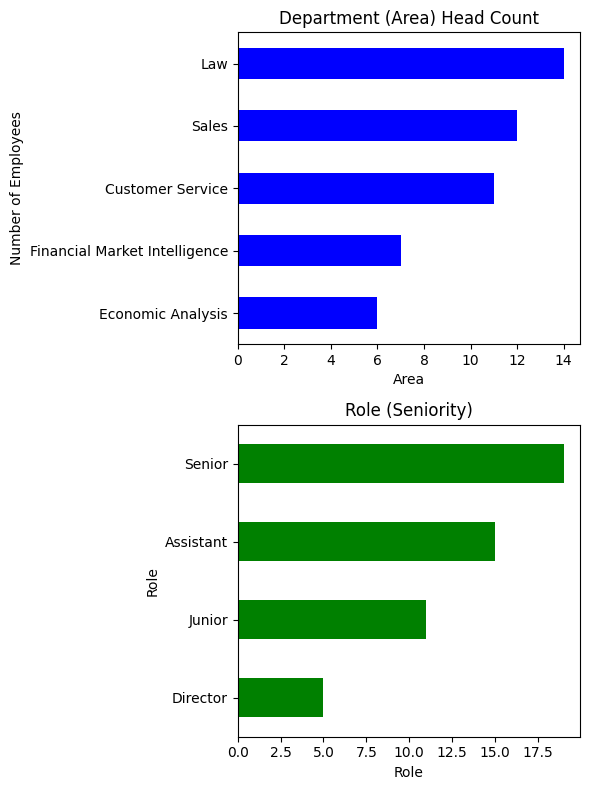

In [139]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8))

nodes['Area'].value_counts().sort_values().plot(kind='barh', color='blue', ax=ax1)
ax1.set_title('Department (Area) Head Count')
ax1.set_xlabel('Area')
ax1.set_ylabel('Number of Employees')


nodes['Role'].value_counts().sort_values().plot(kind='barh', color='green', ax=ax2)
ax2.set_title('Role (Seniority)')
ax2.set_xlabel('Role')
plt.tight_layout()
plt.show()

Law has the highest head count at 14, and Economic Analysis the lowest at 6. Senior is the largest category of any of the levels. Director is smallest, as you might expect.  

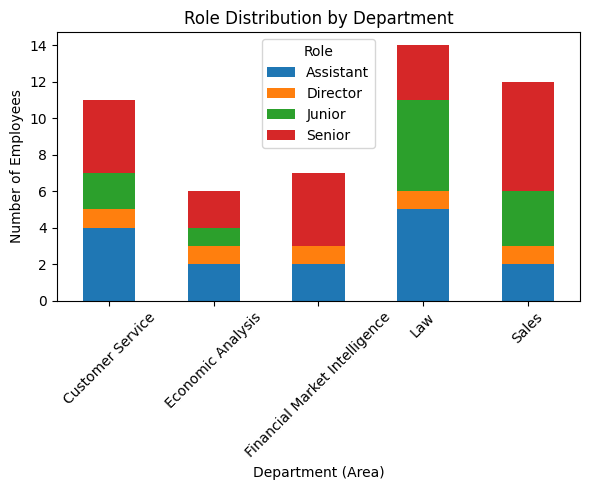

In [62]:
fig, ax = plt.subplots(figsize=(6, 5))

role_by_area = pd.crosstab(nodes['Area'], nodes['Role'])

role_by_area.plot(
    kind='bar',
    stacked=True,
    ax=ax
)

ax.set_title('Role Distribution by Department')
ax.set_xlabel('Department (Area)')
ax.set_ylabel('Number of Employees')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

There are no junior employees in Financial Market Intelligence, but many in Law. Sales includes the most Senior employees.  

**Look at individual departments**  

Create lists of employee numbers by department.  

In [63]:
employees_by_dept = nodes.groupby('Area')['EmployeeID'].apply(list).to_dict()
list(nodes['Area'].unique())

['Law',
 'Financial Market Intelligence',
 'Sales',
 'Customer Service',
 'Economic Analysis']

Filter edges where source and target are in the same department.  

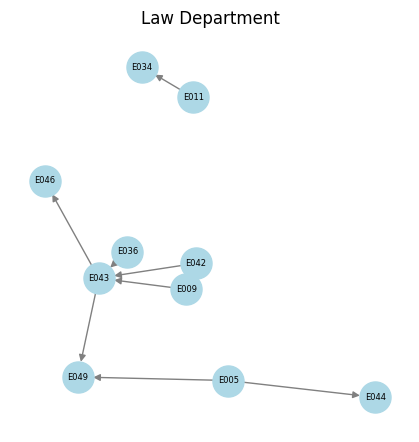

In [89]:
circle_size = 500

dept = 'Law'
Law_dept = edges[edges['Source'].isin(employees_by_dept[dept]) & edges['Target'].isin(employees_by_dept[dept])].reset_index(drop=True)

G = nx.DiGraph()  # Directional graph

G.add_edges_from([(u1, u2) for u1, u2 in zip(Law_dept['Source'], Law_dept['Target'])])

plt.figure(figsize=(4,4))
pos = nx.spring_layout(G, seed=42)  # Layout for visualization
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=circle_size, font_size=6, arrows=True)
plt.title(f'{dept} Department')
plt.show()

The Law department is the largest department, with 14 employees. Ten nodes are included here, which suggests high intra-departmental collaboration. Except for two employees who are paired alone together, the remainder are connected to the larger group in some way. E043 serves as a hub between multiple employees.

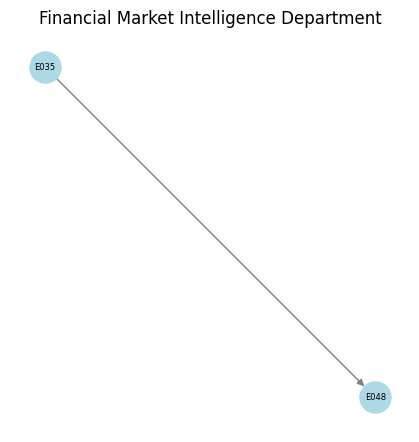

In [90]:
dept = 'Financial Market Intelligence'
Fin_dept = edges[edges['Source'].isin(employees_by_dept[dept]) & edges['Target'].isin(employees_by_dept[dept])].reset_index(drop=True)

G = nx.DiGraph()  # Directional graph

G.add_edges_from([(u1, u2) for u1, u2 in zip(Fin_dept['Source'], Fin_dept['Target'])])

plt.figure(figsize=(4,4))
pos = nx.spring_layout(G, seed=42)  # Layout for visualization
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=circle_size, font_size=6, arrows=True)
plt.title(f'{dept} Department')
plt.show()

Financial Market Intelligence is the smallest group, with 6 employees, and the only interaction is between two employees.  

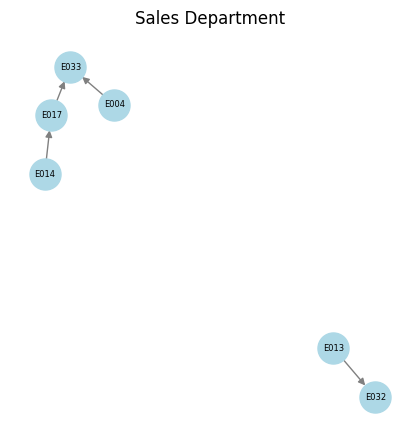

In [91]:
dept = 'Sales'
Sales_dept = edges[edges['Source'].isin(employees_by_dept[dept]) & edges['Target'].isin(employees_by_dept[dept])].reset_index(drop=True)

G = nx.DiGraph()  # Directional graph

G.add_edges_from([(u1, u2) for u1, u2 in zip(Sales_dept['Source'], Sales_dept['Target'])])

plt.figure(figsize=(4,4))
pos = nx.spring_layout(G, seed=42)  # Layout for visualization
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=circle_size, font_size=6, arrows=True)
plt.title(f'{dept} Department')
plt.show()

There are 12 employees total in Sales, only six are shown as having any kind of connection within the department and they are split into two small groups. In one group the communication feeds into E033. The other is a group of two. 

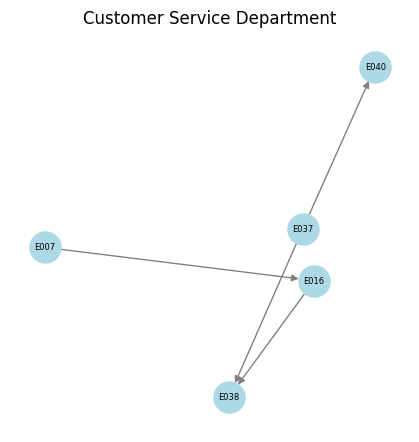

In [92]:
dept = 'Customer Service'
Cust_dept = edges[edges['Source'].isin(employees_by_dept[dept]) & edges['Target'].isin(employees_by_dept[dept])].reset_index(drop=True)

G = nx.DiGraph()  # Directional graph

G.add_edges_from([(u1, u2) for u1, u2 in zip(Cust_dept['Source'], Cust_dept['Target'])])

plt.figure(figsize=(4,4))
pos = nx.spring_layout(G, seed=42)  # Layout for visualization
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=circle_size, font_size=6, arrows=True)
plt.title(f'{dept} Department')
plt.show()

In the Customer Service department, which has eleven employees total, three employees have two intra-departmental connections, and two have one each. 

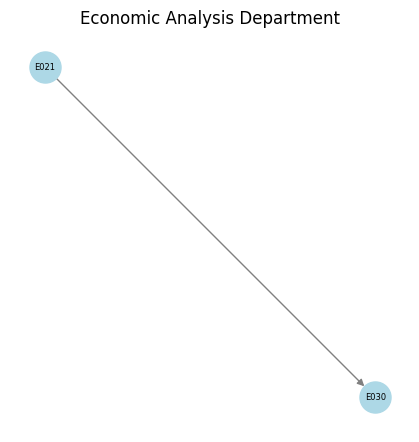

In [93]:
dept = 'Economic Analysis'
Econ_dept = edges[edges['Source'].isin(employees_by_dept[dept]) & edges['Target'].isin(employees_by_dept[dept])].reset_index(drop=True)

G = nx.DiGraph()  # Directional graph

G.add_edges_from([(u1, u2) for u1, u2 in zip(Econ_dept['Source'], Econ_dept['Target'])])

plt.figure(figsize=(4,4))
pos = nx.spring_layout(G, seed=42)  # Layout for visualization
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=circle_size, font_size=6, arrows=True)
plt.title(f'{dept} Department')
plt.show()

The Economic Analysis department shows only two interactions, and it's unidirectional between two employees. They are a small department, with six employees.  

**Whole company**  

In [69]:
list(nodes['Area'].unique())

['Law',
 'Financial Market Intelligence',
 'Sales',
 'Customer Service',
 'Economic Analysis']

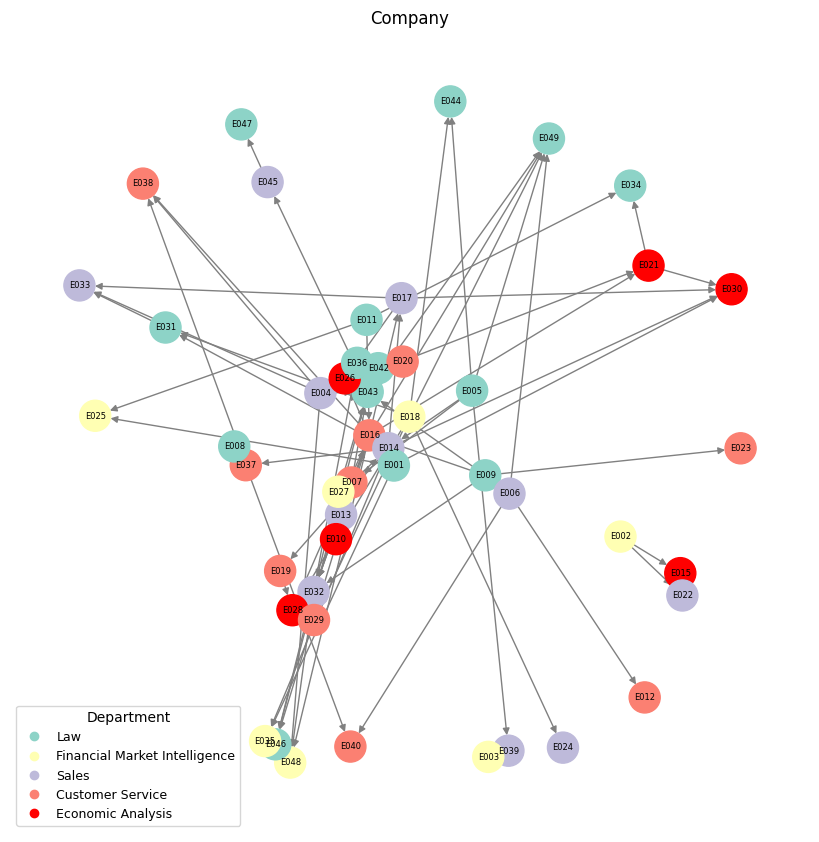

In [94]:
G = nx.DiGraph()  # Directional graph
G.add_edges_from(zip(edges['Source'], edges['Target']))

employee_area = nodes.set_index('EmployeeID')['Area'].to_dict()

# Map Area -> Color
area_colors = dict(zip(
    nodes['Area'].unique(),
    ['#8dd3c7', '#ffffb3', '#bebada', '#fb8072', 'red']
))

# Color each node according to its Area
node_colors = [
    area_colors[employee_area[node]]
    for node in G.nodes()
]

plt.figure(figsize=(8, 8))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    edge_color='gray',
    node_size=circle_size,
    font_size=6,
    arrows=True
)

handles = [
    Line2D([], [], marker='o', linestyle='None',
           markerfacecolor=color, markeredgecolor=color,
           label=area)
    for area, color in area_colors.items()
]

ax = plt.gca()
ax.legend(handles=handles, title='Department', loc='lower left', fontsize=9)

plt.title("Company")

plt.show()

In [86]:
# Compute betweenness centrality
betweenness = nx.betweenness_centrality(G)

# Find the most influential person (highest betweenness)
most_influential = max(betweenness, key=betweenness.get)

# Compute degree centrality
degree = nx.degree_centrality(G)
most_influential_degree = max(degree, key=degree.get)

# Print the most influential people according to each metric
print(f"Most influential person (Betweenness Centrality): {most_influential}", betweenness)
print(f"Most influential person (Degree Centrality): {most_influential_degree}", degree)

Most influential person (Betweenness Centrality): E043 {'E009': 0.0, 'E016': 0.027135368485969782, 'E048': 0.0, 'E038': 0.0, 'E049': 0.0, 'E032': 0.02096823928461301, 'E017': 0.007015109466543325, 'E046': 0.0, 'E028': 0.006475485661424607, 'E013': 0.00786308973172988, 'E007': 0.005164970706136294, 'E018': 0.0, 'E044': 0.0, 'E029': 0.0016188714153561518, 'E024': 0.0, 'E031': 0.0010792476102374343, 'E043': 0.02821461609620722, 'E045': 0.00971322849213691, 'E042': 0.002312673450508788, 'E004': 0.0, 'E026': 0.008556891766882516, 'E036': 0.010175763182238668, 'E014': 0.00786308973172988, 'E019': 0.0018501387604070306, 'E005': 0.0, 'E030': 0.0, 'E037': 0.003006475485661425, 'E001': 0.0, 'E035': 0.0010792476102374343, 'E006': 0.0, 'E011': 0.0, 'E027': 0.0, 'E025': 0.0, 'E047': 0.0, 'E010': 0.0, 'E021': 0.004856614246068455, 'E033': 0.0, 'E034': 0.0, 'E012': 0.0, 'E039': 0.0, 'E008': 0.0, 'E003': 0.0, 'E040': 0.0, 'E020': 0.0, 'E023': 0.0, 'E002': 0.0, 'E015': 0.0, 'E022': 0.0}
Most influentia

Highest Degree Centrality): E016
Highest Betweenness Centrality): E043
Highest Closeness Centrality): E046


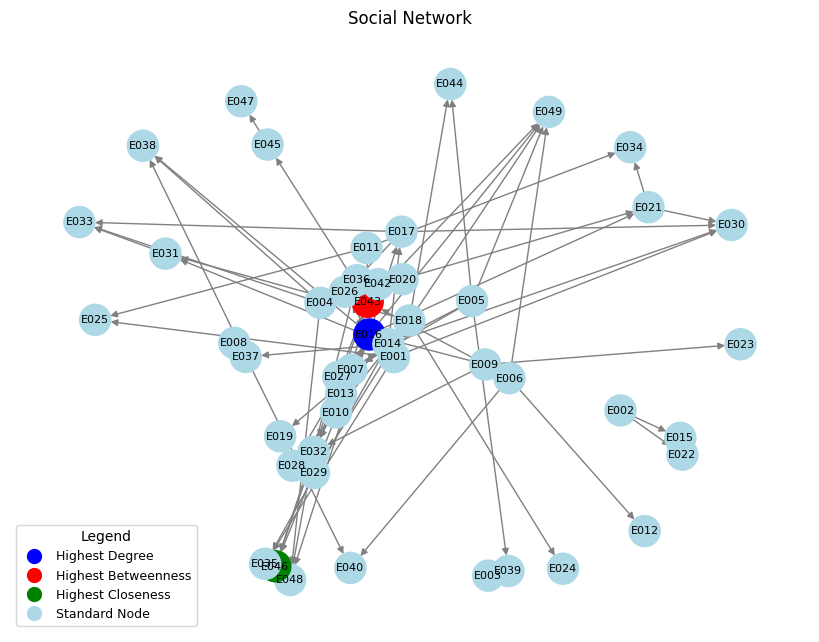

In [ ]:
# Highest number of direct connections (edges) shared with other nodes.
degree = nx.degree_centrality(G)
most_influential_degree = max(degree, key=degree.get)

# How often the node acts as a bridge along the shortest path between all other pairs of nodes
betweenness = nx.betweenness_centrality(G)
most_influential_betweenness = max(betweenness, key=betweenness.get)

# Closest to all other nodes
closeness = nx.closeness_centrality(G)
most_influential_closeness = max(closeness, key=closeness.get)

print(f"Highest Degree Centrality): {most_influential_degree}")
print(f"Highest Betweenness Centrality): {most_influential_betweenness}")
print(f"Highest Closeness Centrality): {most_influential_closeness}")

plt.figure(figsize=(8, 6))
node_colors = ["red" if node == most_influential_betweenness 
               else "blue" if node == most_influential_degree 
               else "green" if node == most_influential_closeness
               else "lightblue" for node in G.nodes()]
nx.draw(G, pos, with_labels=True, node_color=node_colors, edge_color="gray", node_size=circle_size, font_size=8)
plt.title(f"Social Network")

legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='Highest Degree', markerfacecolor='blue', markersize=12),
    plt.Line2D([0], [0], marker='o', color='w', label='Highest Betweenness', markerfacecolor='red', markersize=12),
    plt.Line2D([0], [0], marker='o', color='w', label='Highest Closeness', markerfacecolor='green', markersize=12),
    plt.Line2D([0], [0], marker='o', color='w', label='Standard Node', markerfacecolor='lightblue', markersize=12)
]

plt.legend(handles=legend_elements, title="Legend", loc='lower left', fontsize=9)

plt.show()

Find the top three most influentual employees in each of the centrality categories: degree, betweenness, closeness.

In [115]:
top_three_degree = sorted(
    degree.items(),
    key=lambda x: x[1],
    reverse=True
)[:3]

top_three_employees = [node for node, score in top_three_degree]

top_three_df = nodes[nodes['EmployeeID'].isin(top_three_employees)].copy()

top_three_df['Degree Centrality'] = top_three_df['EmployeeID'].map(degree)

print('Degree Centrality - Top Three')
top_three_df.sort_values(
    'Degree Centrality',
    ascending=False
)

Degree Centrality - Top Three


,EmployeeID,Name,Area,Role,Degree Centrality
15,E016,Alex Johnson,Customer Service,Junior,0.276596
31,E032,Morgan Johnson,Sales,Senior,0.212766
42,E043,Morgan Brown,Law,Assistant,0.212766


Degree Centrality represents the number of direct connections with other nodes. The highest degree centrality is a junior Customer Service employee. This makes sense, because Customer Service should be working across departments to resolve problems. The remainder of the top three are from the Sales and Law departments. 

In [117]:
top_three_betweenness = sorted(
    betweenness.items(),
    key=lambda x: x[1],
    reverse=True
)[:3]

top_three_employees = [node for node, score in top_three_betweenness]

top_three_df = nodes[nodes['EmployeeID'].isin(top_three_employees)].copy()

top_three_df['Betweenness Centrality'] = top_three_df['EmployeeID'].map(betweenness)

print('Betweenness Centrality - Top Three')
top_three_df.sort_values(
    'Betweenness Centrality',
    ascending=False
)

Betweenness Centrality - Top Three


,EmployeeID,Name,Area,Role,Betweenness Centrality
42,E043,Morgan Brown,Law,Assistant,0.028215
15,E016,Alex Johnson,Customer Service,Junior,0.027135
31,E032,Morgan Johnson,Sales,Senior,0.020968


Betweenness Centrality represents the frequency with which a node acts as a bridge along the shortest path between all other pairs of nodes. These are the same top three as the degree centrality category, although in different order. 

In [118]:
top_three_closeness = sorted(
    closeness.items(),
    key=lambda x: x[1],
    reverse=True
)[:3]

top_three_employees = [node for node, score in top_three_closeness]

top_three_df = nodes[nodes['EmployeeID'].isin(top_three_employees)].copy()

top_three_df['Closeness Centrality'] = top_three_df['EmployeeID'].map(closeness)

print('Closeness Centrality - Top Three')
top_three_df.sort_values(
    'Closeness Centrality',
    ascending=False
)

Closeness Centrality - Top Three


,EmployeeID,Name,Area,Role,Closeness Centrality
45,E046,Morgan Smith,Law,Senior,0.199638
48,E049,Jordan Garcia,Law,Assistant,0.198036
42,E043,Morgan Brown,Law,Assistant,0.193424


Nodes with high closeness centrality are closer to all other nodes in the network. In other words, they have the shortest path to all other nodes. These are the employees who can spread information or share resources the most efficiently. Morgan brown also appeared in both the degree and betweenness categories' top three. 

Most employees interact with others in the company, however there are three who stand out as being in an isolated group: E002, E015, E022.

In [129]:
isolated = ['E002','E015','E022']
lone_three = nodes[nodes['EmployeeID'].isin(isolated)].reset_index(drop=True)
lone_three

,EmployeeID,Name,Area,Role
0,E002,Riley Garcia,Financial Market Intelligence,Director
1,E015,Jamie Garcia,Economic Analysis,Assistant
2,E022,Quinn Lewis,Sales,Assistant


These employees come from different departments and include a director-level employee. It's possible that they are remote or focused on a specific project.  